In [33]:
from nba_api.stats.endpoints import leaguedashteamstats
import pandas as pd

#pulling current stats
team_stats = leaguedashteamstats.LeagueDashTeamStats(season='2025-26')
Rankings = team_stats.get_data_frames()[0]

Rankings.head(30)

,TEAM_ID,TEAM_NAME,GP,W,L,W_PCT,MIN,FGM,FGA,FG_PCT,...,REB_RANK,AST_RANK,TOV_RANK,STL_RANK,BLK_RANK,BLKA_RANK,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK
0,1610612737,Atlanta Hawks,82,46,36,0.561,3951.000000,3575,7541,0.474,...,18,1,10,5,18,17,14,26,6,12
1,1610612738,Boston Celtics,82,56,26,0.683,3946.000000,3456,7398,0.467,...,3,27,1,28,11,3,9,27,19,4
2,1610612751,Brooklyn Nets,82,20,62,0.244,3951.000000,3071,6933,0.443,...,30,26,29,22,23,23,26,21,30,28
3,1610612766,Charlotte Hornets,82,44,38,0.537,3951.000000,3357,7292,0.460,...,5,15,25,29,21,9,10,18,13,8
4,1610612741,Chicago Bulls,82,31,51,0.378,3951.000000,3476,7417,0.469,...,9,7,23,23,11,26,8,24,12,22
5,1610612739,Cleveland Cavaliers,82,52,30,0.634,3951.000000,3554,7381,0.482,...,11,8,9,16,13,6,12,7,4,9
6,1610612742,Dallas Mavericks,82,26,56,0.317,3971.000000,3432,7366,0.466,...,10,22,18,24,10,21,2,5,23,23
7,1610612743,Denver Nuggets,82,54,28,0.659,3986.000000,3570,7196,0.496,...,14,4,3,30,28,13,11,3,1,7
8,1610612765,Detroit Pistons,82,60,22,0.732,3961.000000,3560,7340,0.485,...,8,11,21,1,1,29,30,4,8,3
9,1610612744,Golden State Warriors,82,37,45,0.451,3961.000000,3357,7280,0.461,...,21,6,27,2,26,5,13,25,22,20


In [10]:
from nba_api.stats.endpoints import leaguedashteamstats
import pandas as pd

#pulling current stats
team_stats = leaguedashteamstats.LeagueDashTeamStats(season='2025-26')
Rankings = team_stats.get_data_frames()[0]

Rankings_clean = Rankings[['TEAM_NAME', 'W', 'L', 'W_PCT', 'FG_PCT', 'REB', 'AST', 'TOV', 'PTS']]
Rankings_clean = Rankings_clean.sort_values('W_PCT', ascending=False)
Rankings_clean.head(30)

,TEAM_NAME,W,L,W_PCT,FG_PCT,REB,AST,TOV,PTS
20,Oklahoma City Thunder,64,18,0.780,0.484,3618,2113,1031.0,9760
26,San Antonio Spurs,62,20,0.756,0.483,3856,2302,1103.0,9826
8,Detroit Pistons,60,22,0.732,0.485,3736,2281,1241.0,9657
1,Boston Celtics,56,26,0.683,0.467,3802,2021,1014.0,9418
7,Denver Nuggets,54,28,0.659,0.496,3606,2375,1057.0,10010
13,Los Angeles Lakers,53,29,0.646,0.502,3361,2122,1188.0,9540
19,New York Knicks,53,29,0.646,0.478,3740,2250,1119.0,9549
10,Houston Rockets,52,30,0.634,0.479,3946,2083,1261.0,9449
5,Cleveland Cavaliers,52,30,0.634,0.482,3643,2321,1147.0,9801
17,Minnesota Timberwolves,49,33,0.598,0.481,3615,2138,1214.0,9676


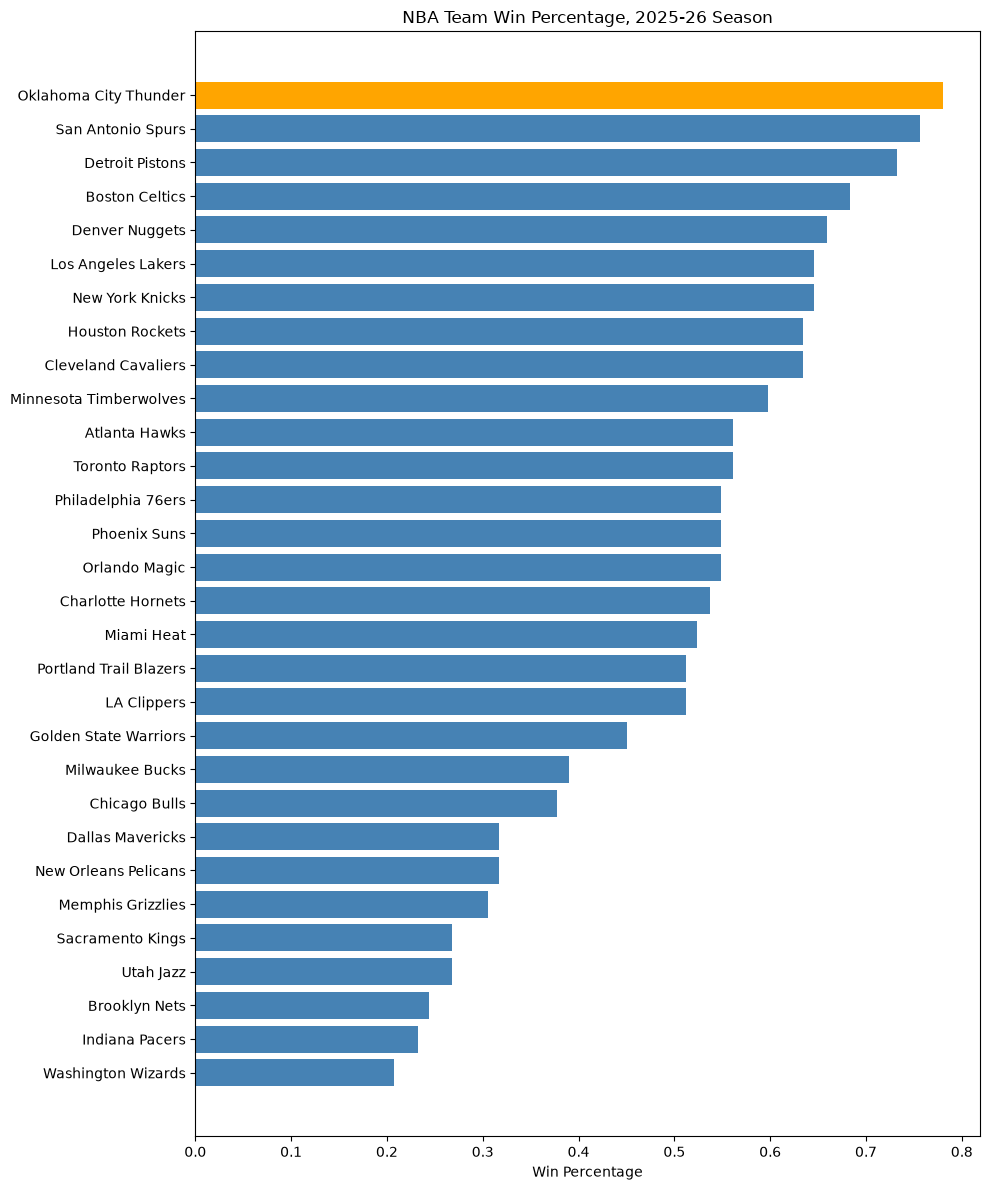

In [51]:
import matplotlib.pyplot as plot

colors = ['orange' if team == 'Oklahoma City Thunder' else 'steelblue' for team in Rankings_clean['TEAM_NAME']] #OKC Orange


plot.figure(figsize=(10,12))
plot.barh(Rankings_clean['TEAM_NAME'], Rankings_clean['W_PCT'], color = colors)
plot.xlabel('Win Percentage')
plot.title('NBA Team Win Percentage, 2025-26 Season')
plot.gca().invert_yaxis() #Highest win percentage on top
plot.tight_layout()
plot.savefig('images/W_PCT_By_Team.png', dpi = 150, bbox_inches ='tight')
plot.show()


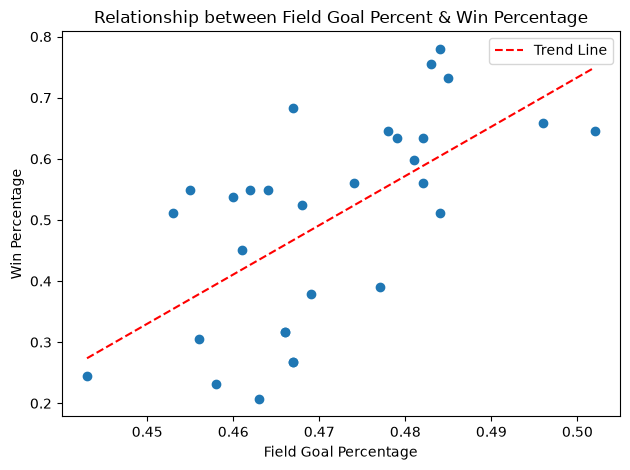

In [50]:
import numpy as np 

plot.Figure(figsize=(8,6))
plot.scatter(Rankings_clean['FG_PCT'], Rankings_clean['W_PCT'])

# fit a straight line
line = np.polyfit(Rankings_clean['FG_PCT'], Rankings_clean['W_PCT'], 1)
trendline = np.poly1d(line)
x_val = np.linspace(Rankings_clean['FG_PCT'].min(), Rankings_clean['FG_PCT'].max(), 100)
plot.plot(x_val, trendline(x_val), color='red', linestyle='--', label = 'Trend Line')

plot.xlabel('Field Goal Percentage')
plot.ylabel('Win Percentage')
plot.title("Relationship between Field Goal Percent & Win Percentage")
plot.legend()
plot.tight_layout()
plot.savefig('images/FG_PCT_VS_W_PCT.png', dpi = 150, bbox_inches ='tight')
plot.show()

In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score

#prediction stats Offensive
stats = ['FG_PCT', 'OREB', 'AST', 'TOV', 'FGM']
x = Rankings[stats]
y = Rankings['W_PCT']

#Training/Testing split
#X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2, random_state=42)

#Model Train
model = LinearRegression()
#model.fit(X_train, Y_train)
scores = cross_val_score(model, x, y, cv=5, scoring = 'r2')

print(f"Cross-validated R2 scores: {scores}")
print(f"Average R2 score: {scores.mean():.2f}")

Cross-validated R2 scores: [ 0.84296715  0.81689952  0.88295988 -0.11323234  0.36013328]
Average R2 score: 0.56


In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score

#prediction stats Defensive
stats = ['STL', 'BLK', 'DREB', 'PF']
x = Rankings[stats]
y = Rankings['W_PCT']

#Model Train
model = LinearRegression()
scores = cross_val_score(model, x, y, cv=5, scoring = 'r2')

print(f"Cross-validated R2 scores: {scores}")
print(f"Average R2 score: {scores.mean():.2f}")

Cross-validated R2 scores: [0.15138766 0.18743383 0.03750619 0.02714924 0.4259213 ]
Average R2 score: 0.17


In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score

#prediction stats Full stats and plus/minus
stats = ['STL', 'BLK', 'DREB', 'PF','FG_PCT', 'OREB', 'AST', 'TOV', 'FGM', 'PLUS_MINUS']
x = Rankings[stats]
y = Rankings['W_PCT']

#Model Train
model = LinearRegression()
scores = cross_val_score(model, x, y, cv=5, scoring = 'r2')

print(f"Cross-validated R2 scores: {scores}")
print(f"Average R2 score: {scores.mean():.2f}")

Cross-validated R2 scores: [0.90027712 0.97108323 0.87964144 0.8343012  0.95127151]
Average R2 score: 0.91


In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score

#prediction stats Full stats without plus/minus
stats = ['STL', 'BLK', 'DREB', 'PF','FG_PCT', 'OREB', 'AST', 'TOV', 'FGM']
x = Rankings[stats]
y = Rankings['W_PCT']

#Model Train
model = LinearRegression()
scores = cross_val_score(model, x, y, cv=5, scoring = 'r2')

print(f"Cross-validated R2 scores: {scores}")
print(f"Average R2 score: {scores.mean():.2f}")

Cross-validated R2 scores: [0.65720393 0.62719238 0.50884437 0.36770895 0.55304251]
Average R2 score: 0.54


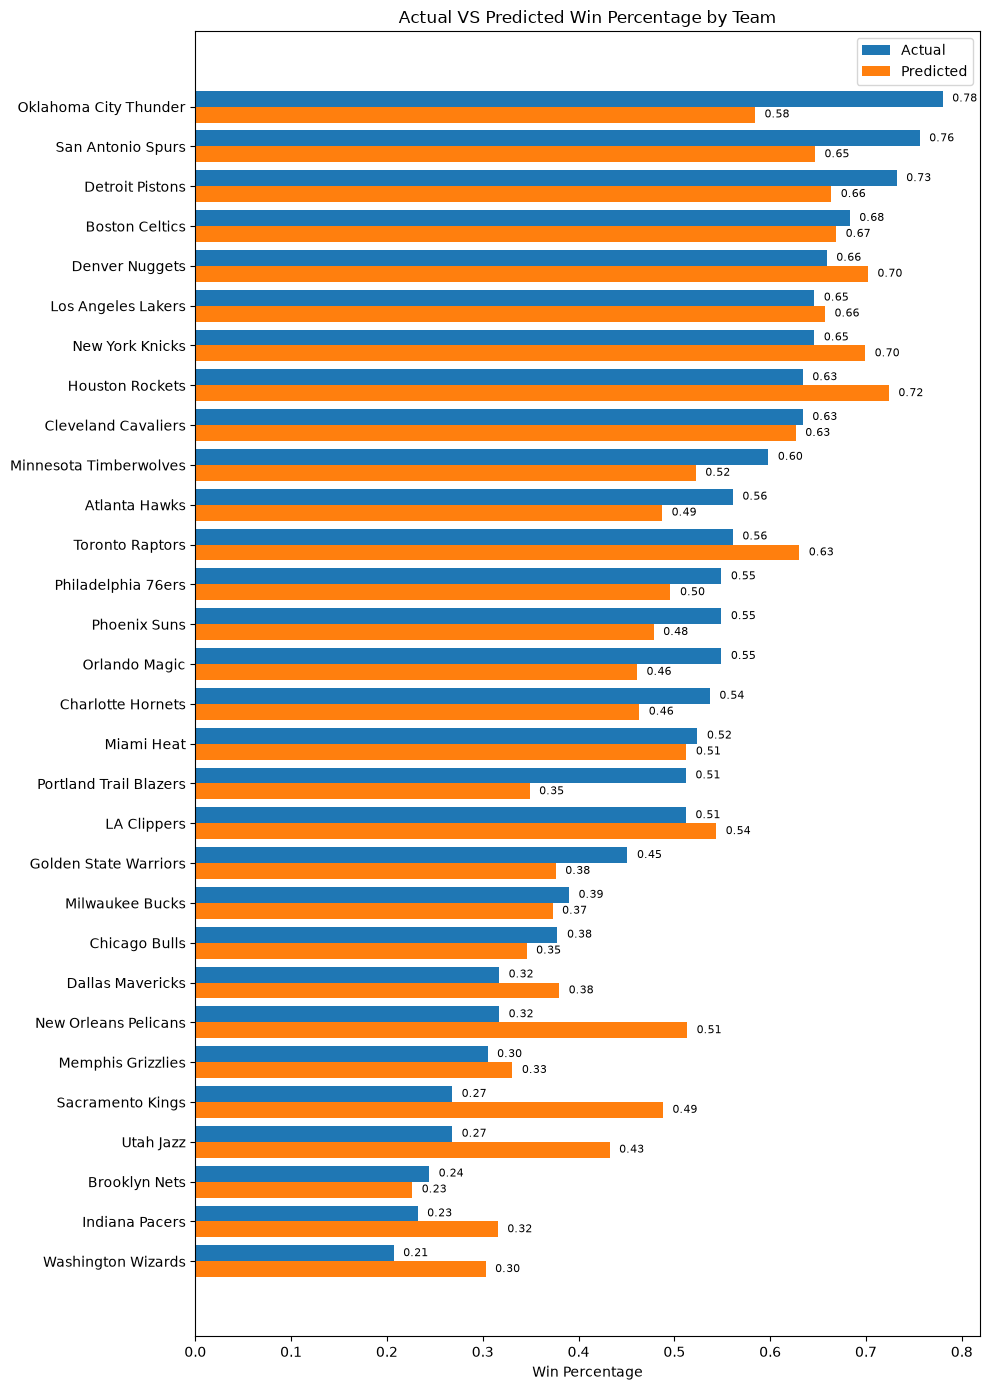

In [56]:
from sklearn.linear_model import LinearRegression

stats = ['FG_PCT', 'OREB', 'AST', 'TOV', 'FGM']
x = Rankings[stats]
y = Rankings['W_PCT']

model = LinearRegression()
model.fit(x, y)
predictions = model.predict(x)

Rankings['Predicted_W_PCT'] = predictions
comparison = Rankings[['TEAM_NAME', 'W_PCT', 'Predicted_W_PCT']].sort_values('W_PCT', ascending = False)

plot.figure(figsize=(10, 14))
y_pos = range(len(comparison))

bar1 = plot.barh(y_pos, comparison['W_PCT'], height=0.4, label='Actual', align='center')
bar2 = plot.barh([p + 0.4 for p in y_pos], comparison['Predicted_W_PCT'], height=0.4, label='Predicted', align='center')

for bar in bar1:
    width = bar.get_width()
    plot.text(width+0.01,bar.get_y()+bar.get_height()/2, f'{width:.2f}', va='center', fontsize = 8)

for bar in bar2:
    width = bar.get_width()
    plot.text(width+0.01,bar.get_y()+bar.get_height()/2, f'{width:.2f}', va='center', fontsize = 8)

plot.yticks([p + 0.2 for p in y_pos], comparison['TEAM_NAME'])
plot.xlabel('Win Percentage')
plot.title('Actual VS Predicted Win Percentage by Team')
plot.gca().invert_yaxis()
plot.legend()
plot.tight_layout()
plot.savefig('images/Predict_Win_PCT_Offensive.png', dpi = 150, bbox_inches ='tight')
plot.show()
